# LSTM for Michael acceptors

 N.B. This notebook is based directly on the equivalent notebook for LSTMs and generative models from the excellent tutorial at [ai4chemistry](https://github.com/schwallergroup/ai4chem_course) by the Schwaller group at ETH Zurich.

* [Recurrent Neural Network (RNN)](https://pubs.acs.org/doi/10.1021/acscentsci.7b00512) this is one of the first examples of using a `RNN`

* Recurrent Neural Network (RNN) with Reinforcement Learning (RL): [Link 1](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-017-0235-x) [Link 2](https://www.science.org/doi/10.1126/sciadv.aap7885) these are also early examples of using a `RNN` but they also couple `RL` to tailor molecular generation towards desired properties

## Recurrent Neural Network (RNN)

#### The code that is imported from `utils` in this section is from [`Rocío Mercado's`](https://rociomer.github.io/) [dl-chem-101 repository](https://github.com/rociomer/dl-chem-101/tree/main/03_gen_SMILES_LSTM)

# 1 Re-training the dl-chem-101 LSTM

We have collected a subset of [ZINC-20](https://zinc.docking.org/), which is a large database of molecules (~1.4B). This set was cleaned and processed and contains both SMILES and SELFIES, provided on the [HuggingFace](https://huggingface.co/datasets/zpn/zinc20/tree/main) platform by [`Zach Nussbaum`](https://huggingface.co/zpn). We have filtered this set for Michael acceptors (SMARTS/SMILES: `"C=CC(O)"`) using RDKit substructure matching to collect Michael acceptors. We have also investigated balancing the dataset for Michael acceptor amides, esters and ketones.

In [ ]:
# need to install the RNN repository as a package (we have a local version of dl-chem-101)
%cd dl-chem-101
%cd 03_gen_SMILES_LSTM
!pip install -e .
%cd "../.."

/home/jp2658/generative/dl-chem-101
/home/jp2658/generative/dl-chem-101/03_gen_SMILES_LSTM
Obtaining file:///home/jp2658/generative/dl-chem-101/03_gen_SMILES_LSTM
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for smiles_lstm (pyproject.toml) ... done
  Created wheel for smiles_lstm: filename=smiles_lstm-1.0.0-0.editable-py3-none-any.whl size=2953 sha256=b42f4e51cd8c1165b4b63193ab5b88bb8e271ed7ff0ebbcea2b54437d278a2f8
  Stored in directory: /tmp/pip-ephem-wheel-cache-70pb9dlc/wheels/b3/e0/99/29eedcc8437bdffad4b2de26271e03ec5e6127819b541af20a
Successfully built smiles_lstm
  Attempting uninstall: smiles_lstm
    Found existing installation: smiles_lstm 1.0.0
    Uninstalling smiles_lstm-1.0.0:
      Successfully uninstalled smiles_lstm-1.0.0
/home/jp2658/generative


In [14]:
# loading in some helper functions (don't worry about the details here for now)
from utils import load_from_file, sample

In [ ]:
"""
Train a SMILES LSTM using ZINC data locally.
Model trains for 10 epochs using the default settings below (~30 mins on a GPU).
"""
import argparse
from pathlib import Path
from smiles_lstm.model.smiles_lstm import SmilesLSTM
from smiles_lstm.model.smiles_trainer import SmilesTrainer
from smiles_lstm.model.smiles_vocabulary import SMILESTokenizer, create_vocabulary
from smiles_lstm.utils import load
from smiles_lstm.utils.misc import suppress_warnings

# set seeds
import random
import numpy as np
import torch
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# suppress minor warnings
suppress_warnings()

print("*** Building a vocabulary from ZINC data ***", flush=True)
zinc_path = Path("./data/")
train     = load.smiles(path=(zinc_path.joinpath("train.smi")))
test      = load.smiles(path=(zinc_path.joinpath("test.smi")))
valid     = load.smiles(path=(zinc_path.joinpath("valid.smi")))

dataset = train + test + valid

test_tokenizer = SMILESTokenizer()
test_vocab     = create_vocabulary(smiles_list=dataset,
                                    tokenizer=test_tokenizer,
                                    canonical=False)

# trainer object expects data in a dictionary, so reorganizing it so
SMILES_dict = {"train" : train, "valid" : valid, "test"  : test}

# define network parameters
network_parameters = {
    'num_layers'          : 3,
    'layer_size'          : 512,
    'cell_type'           : 'lstm',
    'embedding_layer_size': 512,
    'dropout'             : 0.2,
    'layer_normalization' : True,
}
n_epochs = 20 # 10

print("*** Building the SMILES LSTM network and creating a Trainer object with it ***", flush=True)
smiles_lstm = SmilesLSTM(vocabulary=test_vocab,
                            tokenizer=test_tokenizer,
                            network_params=network_parameters)

trainer = SmilesTrainer(model=smiles_lstm,
                        input_smiles=SMILES_dict,
                        epochs=n_epochs,
                        shuffle=True,
                        batch_size=1024, #2048
                        learning_rate=0.0001,
                        augment=3,
                        output_model_path="./lstm/",
                        start_epoch=0,
                        learning_rate_scheduler="StepLR",
                        gamma=0.9,
                        eval_num_samples=256,
                        eval_batch_size=256)

print("*** Training the model ***", flush=True)
trainer.run()

# Free up memory once training is done
import torch
with torch.no_grad(): torch.cuda.empty_cache()

*** Building a vocabulary from ZINC data ***
*** Building the SMILES LSTM network and creating a Trainer object with it ***
*** Training the model ***


100%|##########| 97/97 [00:09<00:00, 10.58it/s]


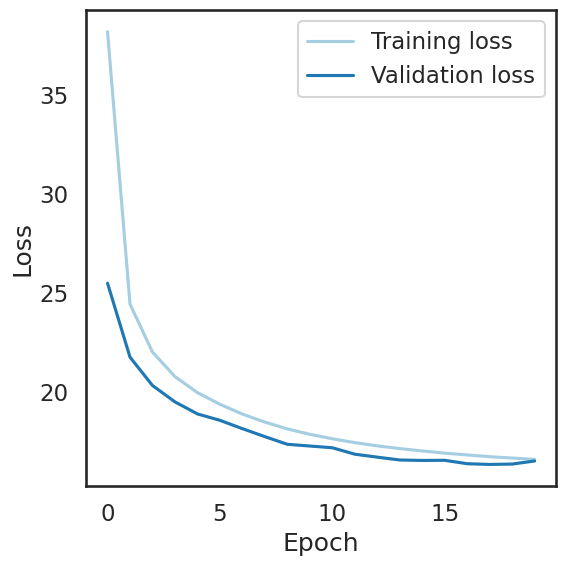

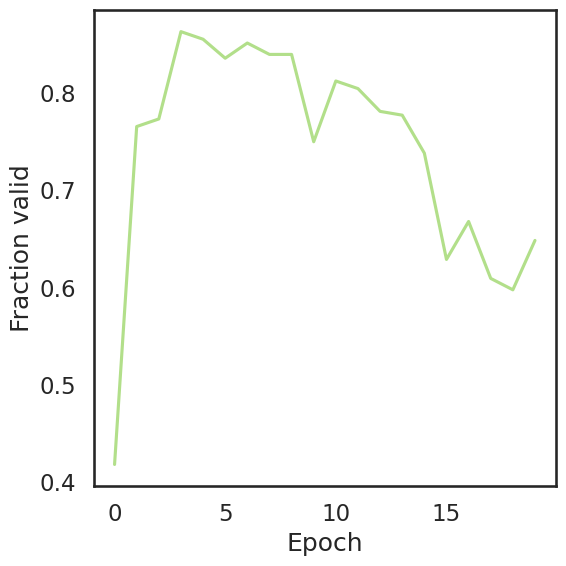

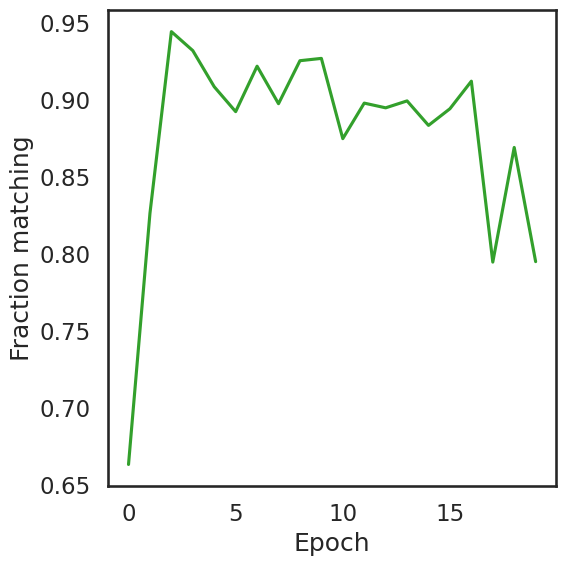

In [19]:
"""
A script which, for each job, plots the following:
1. Training and validation loss
2. Fraction valid
"""
import argparse
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# set Seaborn themes and color palettes
sns.set_theme("talk", "white")
paired_palette = sns.color_palette("Paired")  # for visualizing data that comes in pairs

# load the results from the training job into a pandas DataFrame
jobdir = Path("./lstm/")
data   = pd.read_csv(jobdir.joinpath("SmilesTrainer_training.csv"))

# get each of the values to plot
epochs          = data["epoch"]
training_loss   = data["training loss"]
validation_loss = data["validation loss"]
fraction_valid  = data["fraction valid"]
fraction_matching = data["fraction matching"]

# 01 - plot the training and validation losses
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.plot(epochs, training_loss, label="Training loss", color=paired_palette[0] )
ax.plot(epochs, validation_loss, label="Validation loss", color=paired_palette[1])
ax.legend()
ax.set(xlabel="Epoch", ylabel="Loss")
fig.tight_layout()
fig.savefig(f"./lstm/{jobdir.name}_loss.png")

# 02 - plot the fraction valid
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.plot(epochs, fraction_valid, color=paired_palette[2] )
ax.set(xlabel="Epoch", ylabel="Fraction valid")
fig.tight_layout()
fig.savefig(f"./lstm/{jobdir.name}_fraction_valid.png")

# 03 - plot the fraction matching
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.plot(epochs, fraction_matching, color=paired_palette[3] )
ax.set(xlabel="Epoch", ylabel="Fraction matching")
fig.tight_layout()
fig.savefig(f"./lstm/{jobdir.name}_fraction_matching.png")


# 2. Running molecular generation

In [20]:
# let's begin our dive into gaining a deeper understanding of molecular generative models
# let's load the pre-trained model
pretrained_rnn_model = load_from_file(f'lstm/model.{n_epochs-1}.pth')

In [21]:
from rdkit import Chem
# ok, let's now generate 100 molecules from this model
# keep track of the generated molecules
generated_molecules = []

# for now, don't worry about the "sample()" and "tokenizer" code bits
# the pre-trained model provided actually does not generate valid SMILES strings every time
# we essentially keep generating until we get 100 **valid** molecules

while len(generated_molecules) != 100:
    # generate token sequences
    sequences, nlls = sample(model=pretrained_rnn_model)
    # convert the token sequences into SMILES
    smiles = pretrained_rnn_model.tokenizer.untokenize(pretrained_rnn_model.vocabulary.decode(sequences[0].cpu().numpy()))
    # transform the generated SMILES into RDKit Mol objects
    # the Mol object is "None" if the SMILES cannot be parted by RDKit
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # at this point, the Mol is valid so let's keep track of it
        generated_molecules.append(mol)

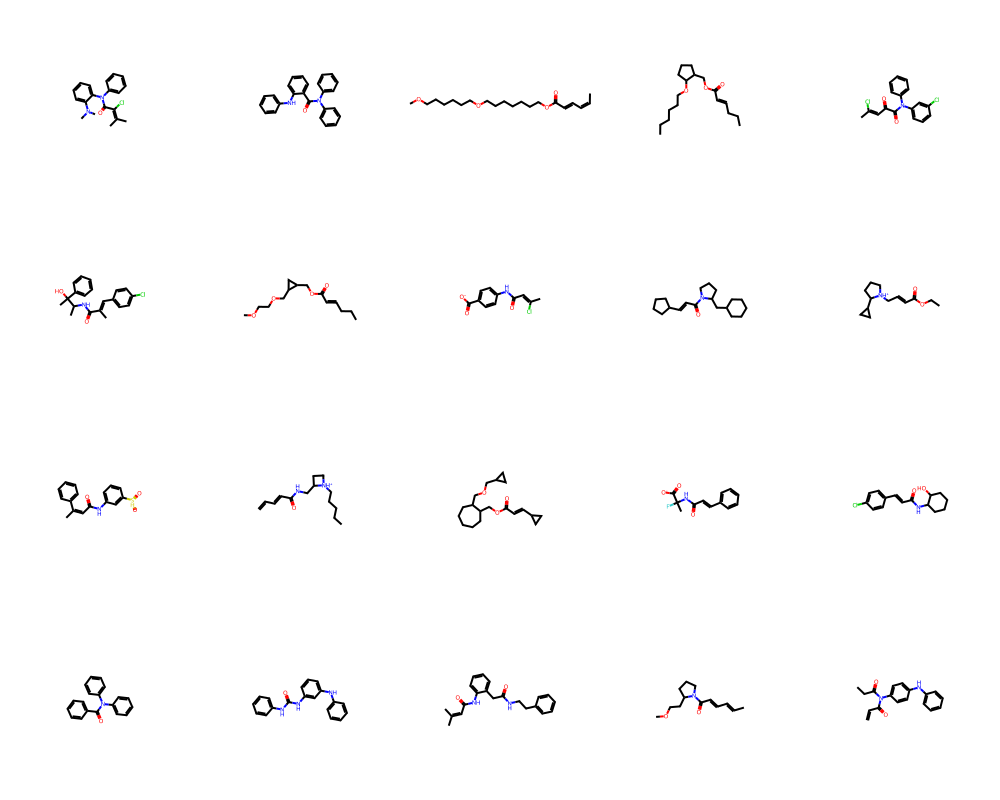

In [22]:
from rdkit.Chem import Draw
# Visualize the first 20 generated molecules
Draw.MolsToGridImage(generated_molecules[:20], molsPerRow=5, subImgSize=(200,200), useSVG=True)

# 3. Analysing generated molecules

These code blocks investigate the qualitative and quantitative properties of molecules generated from the LSTM model. The main properties we will look at are QED (quantitative estimate of drug-likeness - higher is 'better') and SAS (synthetic accessibility score - lower is 'better'); these are easily and quickly computed in RDKit.

In [23]:
# there is a file called "zinc.smi" in the "data" folder that contains 50000 SMILES strings 
# that form the training data for the provided pre-trained model

# with this information, your first task is to check if there is any
# overlap between the SMILES in "zinc.smi" and the generated molecules above

# Task 1: extract the SMILES from "zinc.smi"

### YOUR CODE #####
zinc = []
with open('ZINC/train.smi', 'r') as f:
    # the first line is the header and we don't want this that's why the slice index starts at 1
    for line in f.readlines()[1:]:
        # notice each line actually contains some numbers - we only want the SMILES
        smiles = line.split()[0]
        zinc.append(smiles)

In [24]:
# Task 2: Get the SMILES of the generated molecules from the pre-trained model

# we previously generated 1000 Mol objects from the pre-trained model. We want them in SMILES format
generated_smiles = [Chem.MolToSmiles(mol, canonical=True) for mol in generated_molecules]

In [25]:
# Task 3: Find out how much overlap there is between the generated SMILES 
#         and the training data SMILES (from "zinc.smi")

# we have the SMILES from "zinc.smi", let's convert them to canonical form
zinc = [Chem.CanonSmiles(smiles) for smiles in zinc]

# below wasn't part of the task but for interest
# "set" in Python removes duplicates 
# out of curiosity, are the Zinc SMILES and generated SMILES all unique?
print(f'Number of SMILES in Zinc: {len(zinc)}')
print(f'Number of unique SMILES in Zinc: {len(set(zinc))}')
print(f'Number of generated SMILES: {len(generated_smiles)}')
print(f'Number of unique generated SMILES: {len(set(generated_smiles))}')

# ok, now let's see if there is overlap
overlap = set(generated_smiles).intersection(set(zinc))
print(f'There are {len(overlap)} overlaps and these are the overlapping SMILES: {overlap}')

Number of SMILES in Zinc: 202327
Number of unique SMILES in Zinc: 200854
Number of generated SMILES: 100
Number of unique generated SMILES: 99
There are 0 overlaps and these are the overlapping SMILES: set()


This is significant - this shows that the LSTM SMILES language model can generate molecules **not in the training data**. The overlapping set does not contain fully the set of unique generated SMILES.

But one thing we need to test is how well the generative model can reproduce the desired substructure [`O=CC=CC=O`] for Michael acceptors. We will use RDKit's `HasSubStructMatch` method for this purpose.

In [26]:
smarts = "O=CC=C"
patt = Chem.MolFromSmarts(smarts)

generated_michael = [mol for mol in generated_molecules if mol.HasSubstructMatch(patt)]

print(f'Number of generated molecules: {len(generated_molecules)}')
print(f'Number of Michael acceptors: {len(generated_michael)}')

print(f'Proportion of Michael acceptors generated: {100*len(generated_michael)/len(generated_molecules):.0f}%')

Number of generated molecules: 100
Number of Michael acceptors: 83
Proportion of Michael acceptors generated: 83%


Currently, the proportion of `Michael acceptors` produced is in the majority of total molecules generated, but could definitely be higher. For example, if we trained the model for more (or maybe _fewer_?) `epochs`, or on more Michael acceptors from ZINC (e.g 500K, 1M, 10M), we might expect this proportion to increase.

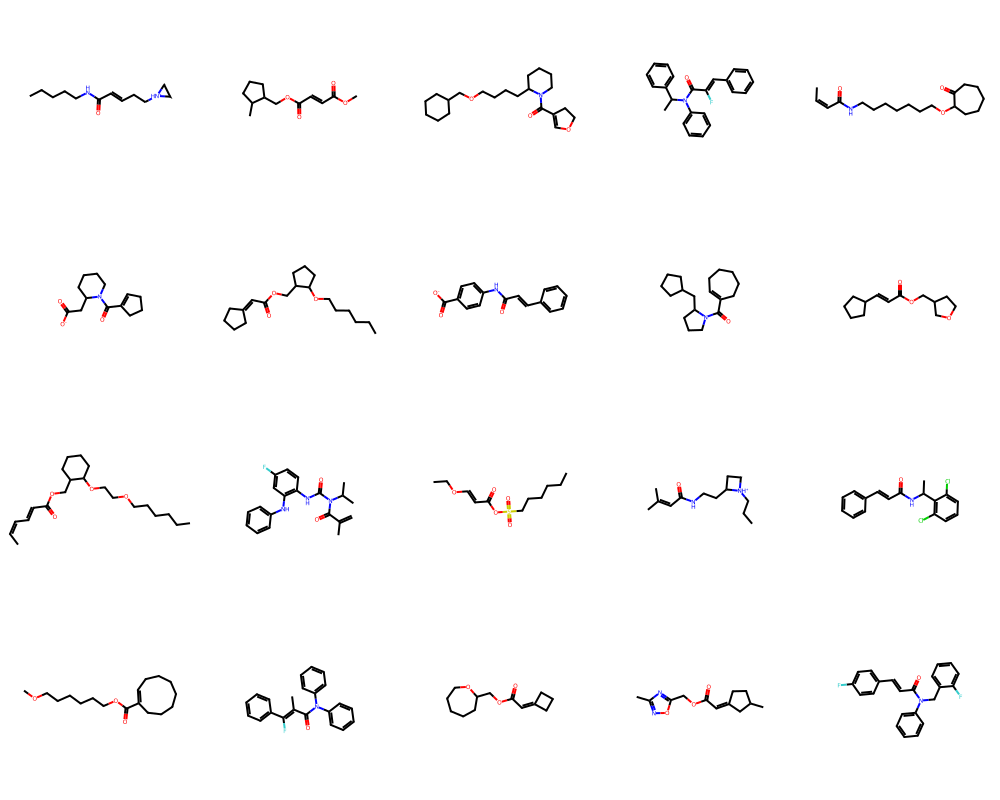

In [27]:
from rdkit.Chem import Draw
# Visualize the first 20 generated molecules
Draw.MolsToGridImage(generated_michael[20:40], molsPerRow=5, subImgSize=(200,200), useSVG=True)

`ZINC` is designed to contain `"drug-like"` molecules, loosely following the empirical [`Lipinski's Rule of 5`](https://www.sciencedirect.com/science/article/pii/S0169409X96004231). `"drug-likeness"` can be quantified by the [`Quantitative Estimate of Drug-likeness (QED) score`](https://www.nature.com/articles/nchem.1243). Your next task is to verify that the `QED` distribution of the `ZINC` training data is reproduced by the pre-trained model.

  0%|          | 0/202327 [00:00<?, ?it/s]

100%|██████████| 202327/202327 [02:01<00:00, 1660.50it/s]


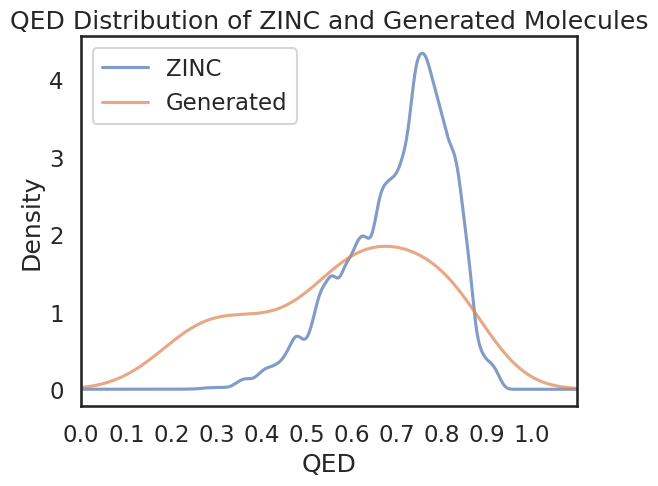

In [28]:
# Task 4: Plot the QED score distribution of ZINC and the generated molecules

from rdkit.Chem.QED import qed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
tqdm.pandas()

# helper function to compute QED - qed function raises an error if there 
# are chemistry violations in the Mol object such as invalid valency
def get_qed(mol):
    try:
        return qed(mol)
    except Exception:
        return 'nan'
    
# make a DataFrame for the ZINC SMILES and compute the QED scores
zinc_df = pd.DataFrame({'smiles': zinc})
zinc_df['qed'] = zinc_df['smiles'].progress_apply(lambda x: get_qed(Chem.MolFromSmiles(x)))

# make a DataFrame for the generated molecules and compute the QED scores
sampled_df = pd.DataFrame({'mols': generated_molecules})
sampled_df['qed'] = sampled_df['mols'].apply(get_qed)

# in case QED could not be computed for some molecules due to some error, remove these
zinc_df = zinc_df.loc[zinc_df['qed'] != 'nan']
sampled_df = sampled_df.loc[sampled_df['qed'] != 'nan']

# # plot to compare distributions
# # "density=True" normalizes the counts since there are more ZINC SMILES than generated SMILES
# zinc_df['qed'].plot(kind='hist', edgecolor='k', alpha=0.3, density=True, label='ZINC')
# sampled_df['qed'].plot(kind='hist', edgecolor='k', alpha=0.3, density=True, label='Generated')
# plt.xlabel('QED'); plt.title('QED Distribution of ZINC and Generated Molecules')
# plt.xticks(np.arange(0, 1.1, 0.1)); plt.legend()

# here's a another view with the "Kernel Density Estimate (KDE))" (estimates the probability distribution)
# create a new instance of figure so we start from a clean slate
plt.figure()
# plot the KDE
zinc_df['qed'].plot(kind='density', alpha=0.7, label='ZINC')
sampled_df['qed'].plot(kind='density', alpha=0.7, label='Generated')
plt.xlabel('QED'); plt.title('QED Distribution of ZINC and Generated Molecules')
plt.xticks(np.arange(0, 1.1, 0.1)); plt.xlim(0, 1.1); plt.legend()

Interestingly, the distribution does not really match the training data, perhaps because a small sample was taken, and probably also because the imperfect reproduction of molecules in the model will likely lead to less (not more) drug-like compounds, such as having complex or large ring systems, very long chains, anti-aromatic rings, or other aberrant molecular features that would not likely make for good drug compounds.

Another important property of molecules proposed by `Molecular Generative Models` is their synthetic accessibility, or the ease at which a chemist could create such as structure. `ZINC` contains a large number of drug-like molecules with good accessibility. `"Synthetic accessibility"` can be quantified by the [`Synthetic accessibility score (SAS)`](https://jcheminf.biomedcentral.com/articles/10.1186/1758-2946-1-8). A __*low*__ SAS score implies the molecule is more accessible, while a __*high*__ score indicates a difficult (long, low yielding) synthesis.

100%|██████████| 202327/202327 [00:30<00:00, 6629.95it/s]


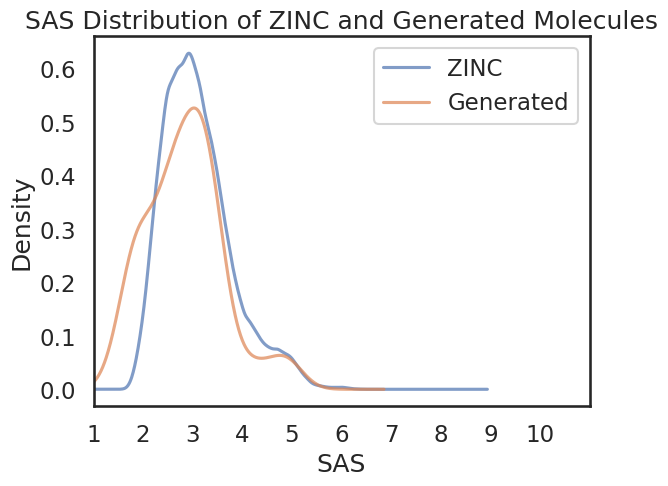

In [29]:
# Task 4: Plot the QED score distribution of ZINC and the generated molecules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
tqdm.pandas()

import sys
import os
sys.path.append(os.path.join(os.environ['CONDA_PREFIX'],'share','RDKit','Contrib'))
from SA_Score import sascorer
from rdkit.Contrib.SA_Score import sascorer


# helper function to compute SAS - sas function raises an error if there 
# are chemistry violations in the Mol object such as invalid valency
def get_sas(mol):
    try:
        return sascorer.calculateScore(mol)
    except Exception:
        return 'nan'
    
# make a DataFrame for the ZINC SMILES and compute the SAS scores
zinc_df = pd.DataFrame({'smiles': zinc})
zinc_df['sas'] = zinc_df['smiles'].progress_apply(lambda x: get_sas(Chem.MolFromSmiles(x)))

# make a DataFrame for the generated molecules and compute the SAS scores
sampled_df = pd.DataFrame({'mols': generated_molecules})
sampled_df['sas'] = sampled_df['mols'].apply(get_sas)

# in case QED could not be computed for some molecules due to some error, remove these
zinc_df = zinc_df.loc[zinc_df['sas'] != 'nan']
sampled_df = sampled_df.loc[sampled_df['sas'] != 'nan']

# "Kernel Density Estimate (KDE))" view (estimates the probability distribution)
# create a new instance of figure so we start from a clean slate
plt.figure()
# plot the KDE
zinc_df['sas'].plot(kind='density', alpha=0.7, label='ZINC')
sampled_df['sas'].plot(kind='density', alpha=0.7, label='Generated')
plt.xlabel('SAS'); plt.title('SAS Distribution of ZINC and Generated Molecules')
plt.xticks(np.arange(1, 11, 1)); plt.xlim(1, 11); plt.legend()

Perhaps surprisingly, the `SAS` of the generated molecules overlaps with the training data, indicating good synthetic accessibility of the generated compounds! However, SAS is only an estimate of synthetic tractability, and subtle differences in structures can lead to great difficulties in a synthetic route, such as chiral centres (stereoselectivity), fused rings, and many functional groups (chemo/regioselectivity).

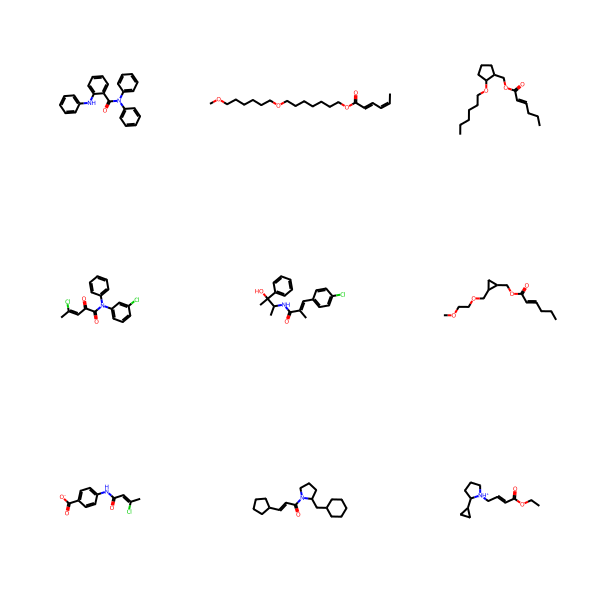

In [31]:
# Task 5: Visually inspect a few of the generated molecules

from rdkit.Chem import Draw

# reasonable looking?
Draw.MolsToGridImage(generated_molecules[1:10])